In [30]:
from collections import defaultdict
from filterpy.kalman import KalmanFilter
import numpy as np
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from collections import defaultdict

In [2]:
%matplotlib inline
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Directory where the .txt files are stored
txt_dir = "/Users/camilla/Desktop/THESIS/PLASTIC_BEACH_THESIS/YOLO_trajectories/runs/detect/track3/labels"

# Initialize an empty list to store data
data = []

# Frame rate (30 frames per second)
fps = 30

# Loop through all the txt files in the directory
for filename in os.listdir(txt_dir):
    if filename.endswith(".txt"):
        # Extract frame number from the filename (e.g., "Videoproject 30_951.txt" -> 951)
        frame_num = int(filename.split('_')[-1].split('.')[0])

        # Read the first line of the txt file (the first row of detections)
        with open(os.path.join(txt_dir, filename), 'r') as file:
            first_line = file.readline().strip()
            if first_line:
                # Parse the data: class_id, x_center, y_center, width, height, object_id
                data_parts = first_line.split()
                class_id = int(data_parts[0])
                x_center = float(data_parts[1])
                y_center = float(data_parts[2])
                width = float(data_parts[3])
                height = float(data_parts[4])

                # Initialize id_number as NaN
                id_number = np.nan

                # Try to get the id_number (if available)
                try:
                    id_number = float(data_parts[6])
                except IndexError:
                    pass  # If no id_number, it will remain NaN

                # Calculate the real time (in seconds)
                real_time = frame_num / fps

                # Append the data as a dictionary to the data list
                data.append({
                    "Frame": frame_num,
                    "Real_Time(s)": real_time,
                    "Class_ID": class_id,
                    "X_Center": x_center,
                    "Y_Center": y_center,
                    "Width": width,
                    "Height": height,
                    'Id_number': id_number
                })

# Convert the list of dictionaries into a pandas DataFrame
df = pd.DataFrame(data)

# Sort the DataFrame by the 'Frame' column (ascending order)
df_sorted = df.sort_values(by='Frame').reset_index(drop=True)

# Convert the normalized X_Center to real-world distance (in cm)
real_width = 292  # real-world width in cm
real_y = 292 * (384/640)
df_sorted['Real_X'] = df_sorted['X_Center'] * real_width
df_sorted['Real_Y'] = df_sorted['Y_Center'] * real_y

# Print the updated dataframe to check
print(df_sorted)


      Frame  Real_Time(s)  Class_ID  X_Center  Y_Center     Width    Height  \
0         1      0.033333         1  0.911135  0.546511  0.018132  0.031199   
1         2      0.066667         1  0.912114  0.546444  0.018367  0.031587   
2         3      0.100000         1  0.913164  0.546726  0.018159  0.031221   
3         4      0.133333         1  0.913741  0.546891  0.018809  0.032290   
4         5      0.166667         1  0.913711  0.547240  0.018928  0.032428   
...     ...           ...       ...       ...       ...       ...       ...   
1326    805     26.833333         0  0.772728  0.478900  0.018156  0.031120   
1327    806     26.866667         0  0.775525  0.479605  0.017782  0.030384   
1328    807     26.900000         0  0.778328  0.481368  0.017117  0.029154   
1329    808     26.933333         0  0.780001  0.481985  0.017390  0.029629   
1330    809     26.966667         0  0.783491  0.483895  0.017086  0.029167   

      Id_number      Real_X     Real_Y  
0         

     Id_number  Class_ID  Frame  Real_Time(s)      Real_X     Real_Y
1          1.0         1      2      0.066667  266.337288  95.736989
2          1.0         1      3      0.100000  266.643888  95.786395
3          1.0         1      4      0.133333  266.812372  95.815303
4          1.0         1      5      0.166667  266.803612  95.876448
5          1.0         1      6      0.200000  266.565632  96.056378
..         ...       ...    ...           ...         ...        ...
195        NaN         1    121      4.033333  231.338168  94.177008
196       54.0         1    121      4.033333  228.105728  90.331018
197        NaN         1    122      4.066667  230.249300  94.009517
198       54.0         1    122      4.066667  228.685348  90.289495
199       35.0         1    123      4.100000  229.561640  94.033870

[199 rows x 6 columns]


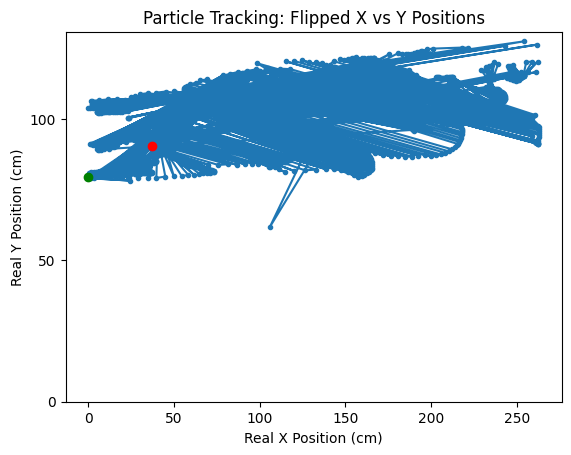

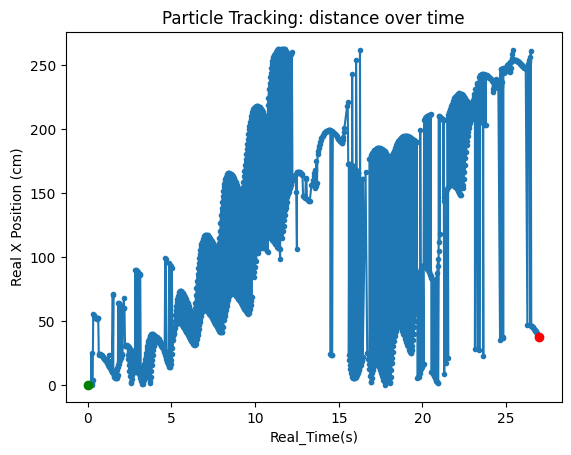

In [3]:
# Create a new dataframe with only the time, Real_X, and Real_Y columns
df_flipped = df_sorted[['Id_number', 'Class_ID', 'Frame', 'Real_Time(s)', 'Real_X', 'Real_Y']].copy()
print(df_flipped[1:200])

# Flip the Real_X and Real_Y to set the origin at the bottom right
df_flipped['Real_X'] = np.abs(df_flipped['Real_X'] - df_flipped['Real_X'][0])  # Flip the X-axis
df_flipped['Real_Y'] = 292 * (384/640) - df_flipped['Real_Y']  # Flip the Y-axis

# Plot the flipped data
plt.plot(df_flipped['Real_X'], df_flipped['Real_Y'], marker='.')
plt.plot(df_flipped['Real_X'][0], df_flipped['Real_Y'][0], marker='o', color='green')
plt.plot(df_flipped['Real_X'][-1:], df_flipped['Real_Y'][-1:], marker='o', color='red')
# Set x-axis ticks from 0 to 2.92 with intervals of 0.50
plt.xticks(np.arange(0, 300, 50))
plt.yticks(np.arange(0, 150, 50))
# Add labels and title
plt.xlabel('Real X Position (cm)')
plt.ylabel('Real Y Position (cm)')
plt.title('Particle Tracking: Flipped X vs Y Positions')

plt.show()


# Plot the flipped data
plt.plot(df_flipped['Real_Time(s)'], df_flipped['Real_X'], marker='.')
plt.plot(df_flipped['Real_Time(s)'][0], df_flipped['Real_X'][0], marker='o', color='green')
plt.plot(df_flipped['Real_Time(s)'][-1:], df_flipped['Real_X'][-1:], marker='o', color='red')

plt.xlabel('Real_Time(s)')
plt.ylabel('Real X Position (cm)')
plt.title('Particle Tracking: distance over time')



# Show the plot
plt.show()
df = df_flipped

In [4]:
# Group detections by frame
detections_by_frame = defaultdict(list)

for _, row in df.iterrows():
    frame = int(row['Frame'])
    detections_by_frame[frame].append({
        'Class_ID': int(row['Class_ID']),
        'X': row['Real_X'],
        'Y': row['Real_Y']
    })


In [62]:
def create_kalman_filter(initial_x, initial_y):
    kf = KalmanFilter(dim_x=4, dim_z=2)
    kf.x = np.array([initial_x, initial_y, 0, 0])
    dt = 1
    kf.F = np.array([[1, 0, dt, 0],
                     [0, 1, 0, dt],
                     [0, 0, 1, 0],
                     [0, 0, 0, 1]])
    kf.H = np.array([[1, 0, 0, 0],
                     [0, 1, 0, 0]])
    kf.P *= 10.
    kf.R *= 5.
    kf.Q *= 0.1
    return kf

class KalmanTracker:
    def __init__(self, dist_threshold=25, max_age=30, min_hits=3):
        self.trackers = []
        self.next_id = 0
        self.dist_threshold = dist_threshold
        self.max_age = max_age
        self.min_hits = min_hits

    def step(self, detections, frame_num):
        class_to_detections = defaultdict(list)
        for d in detections:
            class_to_detections[d['Class_ID']].append(d)

        updated_ids = set()
        new_trackers = []

        for class_id, det_list in class_to_detections.items():
            active_trackers = [t for t in self.trackers if t['class_id'] == class_id]

            # Predict all tracker positions
            predictions = []
            for tracker in active_trackers:
                tracker['kf'].predict()
                tracker['pred'] = np.array([tracker['kf'].x[0], tracker['kf'].x[1]])
                predictions.append(tracker['pred'])

            det_positions = np.array([[d['X'], d['Y']] for d in det_list])

            # Matching
            if len(predictions) > 0 and len(det_positions) > 0:
                dist_matrix = cdist(predictions, det_positions)
                row_idx, col_idx = linear_sum_assignment(dist_matrix)

                assigned_dets = set()

                for t_idx, d_idx in zip(row_idx, col_idx):
                    if dist_matrix[t_idx, d_idx] < self.dist_threshold:
                        tracker = active_trackers[t_idx]
                        det = det_list[d_idx]
                        tracker['kf'].update([det['X'], det['Y']])
                        tracker['hits'] += 1
                        tracker['misses'] = 0
                        tracker['last_frame'] = frame_num
                        tracker['history'].append({
                            'Frame': frame_num,
                            'Track_ID': tracker['id'],
                            'Class_ID': tracker['class_id'],
                            'Real_X': tracker['kf'].x[0],
                            'Real_Y': tracker['kf'].x[1]
                        })
                        updated_ids.add(tracker['id'])
                        assigned_dets.add(d_idx)

                # Unassigned detections → create new trackers
                for i, det in enumerate(det_list):
                    if i not in assigned_dets:
                        kf = create_kalman_filter(det['X'], det['Y'])
                        new_trackers.append({
                            'id': self.next_id,
                            'class_id': det['Class_ID'],
                            'kf': kf,
                            'hits': 1,
                            'misses': 0,
                            'last_frame': frame_num,
                            'history': [{
                                'Frame': frame_num,
                                'Track_ID': self.next_id,
                                'Class_ID': det['Class_ID'],
                                'Real_X': det['X'],
                                'Real_Y': det['Y']
                            }]
                        })
                        self.next_id += 1

            else:
                # No matching possible → all are new
                for det in det_list:
                    kf = create_kalman_filter(det['X'], det['Y'])
                    new_trackers.append({
                        'id': self.next_id,
                        'class_id': det['Class_ID'],
                        'kf': kf,
                        'hits': 1,
                        'misses': 0,
                        'last_frame': frame_num,
                        'history': [{
                            'Frame': frame_num,
                            'Track_ID': self.next_id,
                            'Class_ID': det['Class_ID'],
                            'Real_X': det['X'],
                            'Real_Y': det['Y']
                        }]
                    })
                    self.next_id += 1

        # Update unmatched existing trackers (increment their misses)
        for tracker in self.trackers:
            if tracker['id'] not in updated_ids:
                tracker['misses'] += 1

        # Keep valid ones and merge with new
        self.trackers = [
            t for t in self.trackers if t['misses'] <= self.max_age
        ] + new_trackers
        #print(f"[Frame {frame_num}] Detections: {sum(len(v) for v in class_to_detections.values())}, Tracks: {len(self.trackers)}")

    def get_trajectories(self):
        result = []
        for t in self.trackers:
            if t['hits'] >= self.min_hits:
                result.append(pd.DataFrame(t['history']))
        return result


In [77]:
tracker = KalmanTracker(dist_threshold=7, max_age=100, min_hits=1)

for frame in sorted(detections_by_frame.keys()):
    tracker.step(detections_by_frame[frame], frame)

trajectories = tracker.get_trajectories()
print("Track summary:")
for t in tracker.trackers:
    print(f"Track {t['id']}: class {t['class_id']}, hits = {t['hits']}, frames = {len(t['history'])}")

print("\nTotal tracks created:", tracker.next_id)
print("Tracks that survived:", len(tracker.trackers))
print("Tracks in kalman_df:", kalman_df['Track_ID'].nunique())

for t in tracker.trackers:
    print(f"Track {t['id']} | Hits: {t['hits']} | Misses: {t['misses']} | Class: {t['class_id']}")


kalman_df = pd.concat(trajectories, ignore_index=True)


Track summary:
Track 38: class 2, hits = 111, frames = 111
Track 44: class 0, hits = 40, frames = 40
Track 45: class 0, hits = 5, frames = 5
Track 46: class 0, hits = 26, frames = 26
Track 47: class 0, hits = 21, frames = 21
Track 48: class 2, hits = 45, frames = 45
Track 49: class 0, hits = 3, frames = 3

Total tracks created: 50
Tracks that survived: 7
Tracks in kalman_df: 7
Track 38 | Hits: 111 | Misses: 65 | Class: 2
Track 44 | Hits: 40 | Misses: 92 | Class: 0
Track 45 | Hits: 5 | Misses: 96 | Class: 0
Track 46 | Hits: 26 | Misses: 49 | Class: 0
Track 47 | Hits: 21 | Misses: 0 | Class: 0
Track 48 | Hits: 45 | Misses: 15 | Class: 2
Track 49 | Hits: 3 | Misses: 45 | Class: 0


In [78]:
print(kalman_df.head())
print(kalman_df['Track_ID'].nunique(), "trajectories found.")

   Frame  Track_ID  Class_ID      Real_X     Real_Y
0    603        38         2  207.055448  98.248656
1    604        38         2  207.577129  98.532763
2    605        38         2  208.341960  98.571558
3    606        38         2  209.168776  98.439237
4    607        38         2  209.816421  98.381957
7 trajectories found.


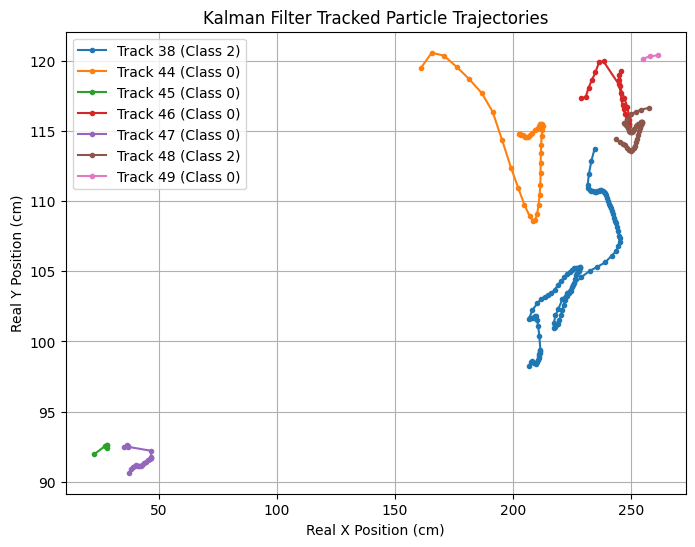

7

In [79]:
plt.figure(figsize=(8, 6))

for tid, group in kalman_df.groupby('Track_ID'):
    plt.plot(group['Real_X'], group['Real_Y'], marker='.', linestyle='-',
             label=f'Track {tid} (Class {group["Class_ID"].iloc[0]})')

plt.xlabel('Real X Position (cm)')
plt.ylabel('Real Y Position (cm)')
plt.title('Kalman Filter Tracked Particle Trajectories')
plt.grid(True)
plt.legend()
plt.show()
kalman_df['Track_ID'].nunique()

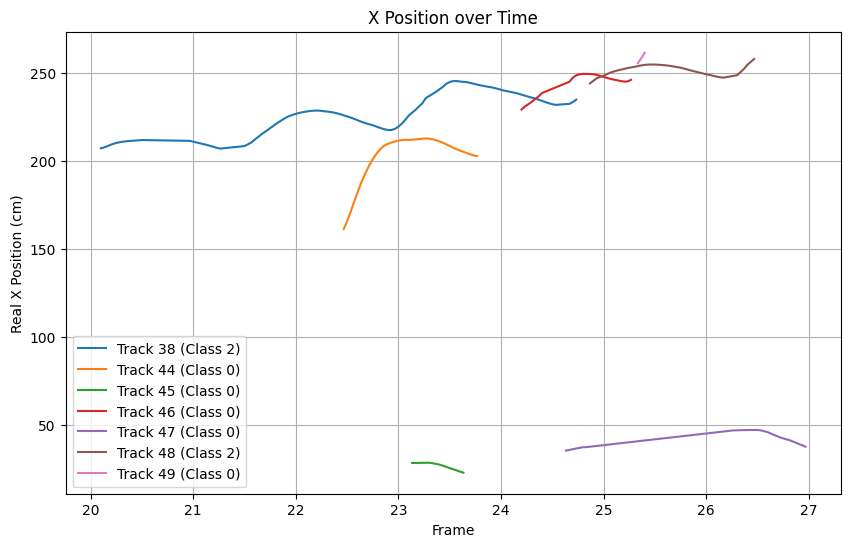

In [80]:
plt.figure(figsize=(10, 6))


for tid, group in kalman_df.groupby('Track_ID'):
    plt.plot(group['Frame']/30, group['Real_X'], label=f'Track {tid} (Class {group["Class_ID"].iloc[0]})')

plt.xlabel("Frame")
plt.ylabel("Real X Position (cm)")
plt.title("X Position over Time")
plt.grid(True)
plt.legend()
plt.show()
